In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict

c:\Users\Muhammad Hashir\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [19]:
class BMIState(TypedDict):
    height_m : float
    weight_kg : float
    bmi : float
    category : str

graph = StateGraph(BMIState)

In [20]:
def calculate_bmi(state:BMIState) -> BMIState:

    weight = state["weight_kg"]
    height = state["height_m"]
    bmi = weight / (height ** 2)
    

    state["bmi"] = round(bmi, 2)
        
    return state

In [21]:
def calculate_category(state:BMIState) -> BMIState:
    bmi = state["bmi"]
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 25:
        category = "Normal weight"
    elif 25 <= bmi < 30:
        category = "Overweight"
    else:
        category = "Obese"

    state["category"] = category
    return state
    

In [22]:
graph = StateGraph(BMIState)
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("calculate_category", calculate_category)


graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "calculate_category")
graph.add_edge("calculate_category", END)

workflow = graph.compile()

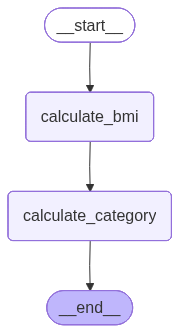

In [23]:
workflow

In [25]:
workflow.invoke(
    {
        "height_m": 1.75,
        "weight_kg": 55
    }
)

{'height_m': 1.75, 'weight_kg': 55, 'bmi': 17.96, 'category': 'Underweight'}